# 🚀 Vectyfi Radar — ML Model for EU Public Tender Prediction

**Goal:** Predict whether a public tender will result in a contract award.

**Dataset:** TED (Tenders Electronic Daily) — Contract Forming Cycle 2018–2023

**ML Task:** Binary Classification → awarded (1) vs. not awarded (0)

 ## Step-by-Step Overview

 1. **Setup & Imports** — Load libraries
 2. **Data Loading** — Efficient loading of 3.6GB dataset
 3. **Exploratory Data Analysis (EDA)** — Understand the data
 4. **Feature Engineering** — Build features for the model
 5. **Train/Test Split** — Split the data
 6. **Baseline Model** — Logistic Regression
 7. **Advanced Model** — XGBoost
 8. **Evaluation & Comparison** — How good are our models?
 9. **Feature Importance** — What drives the prediction?
 10. **Cross-Validation** — How stable is the model?
 11. **Threshold Tuning** — Optimize decision boundary
 12. **Business KPIs** — Real-world impact simulation
 13. **Optuna Hyperparameter Tuning** — Automated optimization
 14. **Conclusion & Next Steps** — Summary and SaaS outlook

 ---
 ## 1. Setup & Imports

 First, we load all the libraries we need. If any are missing: `pip install <name>`

In [30]:
# %%
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, recall_score,
    precision_score, precision_recall_curve, fbeta_score
)

# Settings
pd.set_option('display.max_columns', 70)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

print('✅ All imports loaded successfully!')

# XGBoost
try:
    from xgboost import XGBClassifier
    print('✅ XGBoost loaded')
except ImportError:
    print('⚠️ XGBoost not installed. Run: pip install xgboost')

✅ All imports loaded successfully!
✅ XGBoost loaded


In [31]:
file_path = '/Users/basile/code/Tescoa00/raw_data/export_CFC_2018_2023.csv'

df_raw = pd.read_csv(
    file_path,
    nrows=500_000,
    low_memory=False
)

print(f'✅ Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'💾 Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

✅ Loaded: 500,000 rows × 64 columns
💾 Memory usage: 1256.2 MB


In [32]:
df_raw.head()

,ID_NOTICE_CN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,FUTURE_CAN_ID,FUTURE_CAN_ID_ESTIMATED,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,ISO_COUNTRY_CODE,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_SINGLE_OPERATOR,FRA_NUMBER_OPERATORS,FRA_NUMBER_MAX_OPERATORS,B_DYN_PURCH_SYST,CPV,ID_LOT,ADDITIONAL_CPVS,B_GPA,LOTS_NUMBER,LOTS_SUBMISSION,B_VARIANTS,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_OPTIONS,B_EU_FUNDS,B_RENEWALS,DURATION,CONTRACT_START,CONTRACT_COMPLETION,TOP_TYPE,B_ACCELERATED,ENV_OPERATORS,ENV_MIN_OPERATORS,ENV_MAX_OPERATORS,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,DT_APPLICATIONS,B_LANGUAGE_ANY_EC,ADMIN_LANGUAGES_TENDER,ADMIN_OTHER_LANGUAGES_TENDER,B_RECURRENT_PROCUREMENT
0,20181,ted.europa.eu/udl?uri=TED:NOTICE:1-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.021265e+09,0,N,Innovative Medicines Initiative 2 Joint Undert...,NaN,IMI2 JU — TO 56 1049 Brussels; Belgium,Brussels,1060,BE,N,NaN,5,AG,Health,Y,Y,N,S,BE10,Y,NaN,N,3.0,3.0,N,79200000.0,NaN,79210000,N,1.0,NaN,N,1.0,1.0,1.0,N,Y,Y,36.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,05/02/18,NaN,BG|CS|DA|DE|EL|EN|ES|ET|FI|FR|GA|HR|HU|IT|LT|L...,NaN,N
1,20181,ted.europa.eu/udl?uri=TED:NOTICE:1-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.022329e+09,0,N,Innovative Medicines Initiative 2 Joint Undert...,NaN,IMI2 JU — TO 56 1049 Brussels; Belgium,Brussels,1060,BE,N,NaN,5,AG,Health,Y,Y,N,S,BE10,Y,NaN,N,3.0,3.0,N,79200000.0,NaN,79210000,N,1.0,NaN,N,1.0,1.0,1.0,N,Y,Y,36.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,05/02/18,NaN,BG|CS|DA|DE|EL|EN|ES|ET|FI|FR|GA|HR|HU|IT|LT|L...,NaN,N
2,20182,ted.europa.eu/udl?uri=TED:NOTICE:2-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.018490e+09,0,N,Translation Centre for the Bodies of the Europ...,NaN,"Bâtiment Drosbach 12E, rue Guillaume Kroll",Luxembourg,L-1882 -Luxembourg,LU,N,NaN,5,AG,Other,Y,N,Y,S,LU000,Y,NaN,N,15.0,15.0,N,79530000.0,1,79530000,N,23.0,NaN,N,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,13/02/18,NaN,EN|BG|DA|DE|EL|ET|FI|FR|GA|HR|HU|IT|LV|LT|MT|N...,NaN,N
3,20182,ted.europa.eu/udl?uri=TED:NOTICE:2-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.018490e+09,0,N,Translation Centre for the Bodies of the Europ...,NaN,"Bâtiment Drosbach 12E, rue Guillaume Kroll",Luxembourg,L-1882 -Luxembourg,LU,N,NaN,5,AG,Other,Y,N,Y,S,LU000,Y,NaN,N,15.0,15.0,N,79530000.0,10,79530000,N,23.0,NaN,N,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,13/02/18,NaN,EN|BG|DA|DE|EL|ET|FI|FR|GA|HR|HU|IT|LV|LT|MT|N...,NaN,N
4,20182,ted.europa.eu/udl?uri=TED:NOTICE:2-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.018490e+09,0,N,Translation Centre for the Bodies of the Europ...,NaN,"Bâtiment Drosbach 12E, rue Guillaume Kroll",Luxembourg,L-1882 -Luxembourg,LU,N,NaN,5,AG,Other,Y,N,Y,S,LU000,Y,NaN,N,15.0,15.0,N,79530000.0,11,79530000,N,23.0,NaN,N,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,13/02/18,NaN,EN|BG|DA|DE|EL|ET|FI|FR|GA|HR|HU|IT|LV|LT|MT|N...,NaN,N


In [33]:
# Affiche toutes les colonnes avec leur type et % de valeurs manquantes
summary = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'missing_%': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'unique': df_raw.nunique(),
    'example': df_raw.iloc[0]
})
print(summary.to_string())


                                dtype  missing_%  unique                                                                  example
ID_NOTICE_CN                    int64        0.0   95121                                                                    20181
TED_NOTICE_URL                    str        0.0   95121                     ted.europa.eu/udl?uri=TED:NOTICE:1-2018:TEXT:EN:HTML
YEAR                            int64        0.0       6                                                                     2018
ID_TYPE                         int64        0.0      10                                                                        2
DT_DISPATCH                       str        0.0     208                                                                 22/12/17
XSD_VERSION                       str        0.0       6                                                                  R209.S2
CANCELLED                       int64        0.0       2                                  

In [34]:
features = [
    'VALUE_EURO',
    'TYPE_OF_CONTRACT',
    'TOP_TYPE',
    'CPV',
    'CRIT_CODE',
    'B_FRA_AGREEMENT',
    'LOTS_NUMBER',
    'ISO_COUNTRY_CODE',
    'DURATION',
    'MAIN_ACTIVITY',
    'B_EU_FUNDS',
    'DT_DISPATCH',
    'CRIT_PRICE_WEIGHT',
    'B_GPA',
    'TAL_LOCATION_NUTS',
    'B_DYN_PURCH_SYST',
    'B_ELECTRONIC_AUCTION',
    'B_RECURRENT_PROCUREMENT',
    'B_OPTIONS',
    'B_RENEWALS',
    'B_ACCELERATED',
    'CORRECTIONS',
    'XSD_VERSION',
    'B_MULTIPLE_CAE',
    'B_ON_BEHALF',
    'DT_APPLICATIONS',
    'FUTURE_CAN_ID'
]

available = [col for col in features if col in df_raw.columns]
missing = set(features) - set(available)

if missing:
    print(f"⚠️ Colonnes absentes : {missing}")

select_df = df_raw[available].copy()
print(f"✅ DataFrame : {select_df.shape[0]:,} rows * {select_df.shape[1]} columns")

✅ DataFrame : 500,000 rows * 27 columns


In [ ]:
select_df['awarded'] = select_df['FUTURE_CAN_ID'].notna().astype(int)
select_df = select_df.drop(columns=['FUTURE_CAN_ID'])

print('=== Target Distribution ===')
print(select_df['awarded'].value_counts())
print()
print(f"Award Rate/baseline: {select_df['awarded'].mean()*100:.1f}%")

=== Target Distribution ===
awarded
1    439928
0     60072
Name: count, dtype: int64

Award Rate/baseline: 88.0%


In [ ]:
select_df = df_raw[available].copy()

for col in ['DT_DISPATCH', 'DT_APPLICATIONS']:
    if col in select_df.columns:
        select_df[col] = pd.to_datetime(select_df[col], dayfirst=True, format='mixed', errors='coerce')

select_df['cpv4'] = select_df['CPV'].astype(str).str[:4]
select_df['month_dispatch'] = select_df['DT_DISPATCH'].dt.month if 'DT_DISPATCH' in select_df.columns else 0
select_df['is_end_of_year'] = select_df['month_dispatch'].isin([11, 12]).astype(int)
select_df['days_to_deadline'] = (
    (select_df['DT_APPLICATIONS'] - select_df['DT_DISPATCH']).dt.days.clip(0, 365).fillna(30)
    if 'DT_DISPATCH' in select_df.columns and 'DT_APPLICATIONS' in select_df.columns
    else 30
)
select_df['has_value'] = (select_df['VALUE_EURO'] > 0).astype(int)
select_df['has_corrections'] = (select_df['CORRECTIONS'] > 0).astype(int)

select_df = select_df.drop(columns=['DT_DISPATCH', 'DT_APPLICATIONS'], errors='ignore')

df_v1 = select_df
print(f"New columns: {df_v1.shape[1]} total")

In [ ]:
cat_cols = select_df.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles à encoder : {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    select_df[col] = le.fit_transform(select_df[col].astype(str))
    le_dict[col] = le

# Vérification
print(f"Types restants :\n{select_df.dtypes.value_counts()}")
print(f"NaN restants : {select_df.isna().sum().sum()}")

/var/folders/cl/mppq8yt10c97fj6yy0jmm5gm0000gn/T/ipykernel_42665/4227142271.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = select_df.select_dtypes(include=['object']).columns.tolist()


Colonnes catégorielles à encoder : ['TYPE_OF_CONTRACT', 'TOP_TYPE', 'CRIT_CODE', 'B_FRA_AGREEMENT', 'ISO_COUNTRY_CODE', 'MAIN_ACTIVITY', 'B_EU_FUNDS', 'CRIT_PRICE_WEIGHT', 'B_GPA', 'TAL_LOCATION_NUTS', 'B_DYN_PURCH_SYST', 'B_ELECTRONIC_AUCTION', 'B_RECURRENT_PROCUREMENT', 'B_OPTIONS', 'B_RENEWALS', 'B_ACCELERATED', 'XSD_VERSION', 'B_MULTIPLE_CAE', 'B_ON_BEHALF', 'cpv4']
Types restants :
int64      25
float64     5
int32       1
Name: count, dtype: int64
NaN restants : 247945


In [44]:
df_v1.head()

,VALUE_EURO,TYPE_OF_CONTRACT,TOP_TYPE,CPV,CRIT_CODE,B_FRA_AGREEMENT,LOTS_NUMBER,ISO_COUNTRY_CODE,DURATION,MAIN_ACTIVITY,B_EU_FUNDS,CRIT_PRICE_WEIGHT,B_GPA,TAL_LOCATION_NUTS,B_DYN_PURCH_SYST,B_ELECTRONIC_AUCTION,B_RECURRENT_PROCUREMENT,B_OPTIONS,B_RENEWALS,B_ACCELERATED,CORRECTIONS,XSD_VERSION,B_MULTIPLE_CAE,B_ON_BEHALF,awarded,cpv4,month_dispatch,is_end_of_year,days_to_deadline,has_value,has_corrections
0,1.0,0,5,79200000.0,2,1,1.0,1,36.0,46,1,749,0,128,0,0,0,0,1,1,1,3,0,1,1,950,12,1,45.0,1,1
1,1.0,0,5,79200000.0,2,1,1.0,1,36.0,46,1,749,0,128,0,0,0,0,1,1,1,3,0,1,1,950,12,1,45.0,1,1
2,2400000.0,0,5,79530000.0,2,1,23.0,20,12.0,56,0,749,0,3691,0,0,0,0,1,1,1,3,0,1,1,964,12,1,53.0,1,1
3,2400000.0,0,5,79530000.0,2,1,23.0,20,12.0,56,0,749,0,3691,0,0,0,0,1,1,1,3,0,1,1,964,12,1,53.0,1,1
4,2400000.0,0,5,79530000.0,2,1,23.0,20,12.0,56,0,749,0,3691,0,0,0,0,1,1,1,3,0,1,1,964,12,1,53.0,1,1


In [45]:
X = df_v1.drop(columns=['awarded'])
y = df_v1['awarded']

X = X.fillna(0)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y distribution:\n{y.value_counts()}')
print(f'\nNaN check: {X.isna().sum().sum()} missing values')

X shape: (500000, 30)
y shape: (500000,)
y distribution:
awarded
1    439928
0     60072
Name: count, dtype: int64

NaN check: 0 missing values


### Logistic regression

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {X_train.shape[0]:,} rows ({y_train.mean()*100:.1f}% awarded)')
print(f'Test:     {X_test.shape[0]:,} rows ({y_test.mean()*100:.1f}% awarded)')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression — Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Not Awarded', 'Awarded']))

Training: 400,000 rows (88.0% awarded)
Test:     100,000 rows (88.0% awarded)


/Users/basile/.pyenv/versions/3.14.3/envs/Vectyfi/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression — Results ===
Accuracy:  0.8787
F1 Score:  0.9353
ROC AUC:   0.7647

              precision    recall  f1-score   support

 Not Awarded       0.31      0.01      0.02     12014
     Awarded       0.88      1.00      0.94     87986

    accuracy                           0.88    100000
   macro avg       0.60      0.50      0.48    100000
weighted avg       0.81      0.88      0.82    100000



### XGBoost

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {X_train.shape[0]:,} rows ({y_train.mean()*100:.1f}% awarded)')
print(f'Test:     {X_test.shape[0]:,} rows ({y_test.mean()*100:.1f}% awarded)')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print('\n✅ XGBoost training complete!')

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost — Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Not Awarded', 'Awarded']))

Training: 400,000 rows (88.0% awarded)
Test:     100,000 rows (88.0% awarded)
[0]	validation_0-logloss:0.35001


/Users/basile/.pyenv/versions/3.14.3/envs/Vectyfi/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [19:40:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-logloss:0.22292
[100]	validation_0-logloss:0.20140
[150]	validation_0-logloss:0.18648
[200]	validation_0-logloss:0.17619
[250]	validation_0-logloss:0.16857
[299]	validation_0-logloss:0.16209

✅ XGBoost training complete!
=== XGBoost — Results ===
Accuracy:  0.9327
F1 Score:  0.9630
ROC AUC:   0.9591

              precision    recall  f1-score   support

 Not Awarded       0.92      0.48      0.63     12014
     Awarded       0.93      0.99      0.96     87986

    accuracy                           0.93    100000
   macro avg       0.93      0.74      0.80    100000
weighted avg       0.93      0.93      0.92    100000



=== Feature Importance ===
ISO_COUNTRY_CODE           0.092209
has_value                  0.082042
CRIT_CODE                  0.069366
LOTS_NUMBER                0.054018
B_FRA_AGREEMENT            0.049772
TAL_LOCATION_NUTS          0.046019
B_EU_FUNDS                 0.041389
days_to_deadline           0.037344
cpv4                       0.037201
B_ACCELERATED              0.036136
B_RENEWALS                 0.034922
is_end_of_year             0.030204
XSD_VERSION                0.029128
has_corrections            0.026527
CPV                        0.026002
B_ON_BEHALF                0.025156
CORRECTIONS                0.025063
B_GPA                      0.025015
VALUE_EURO                 0.023806
B_ELECTRONIC_AUCTION       0.023489
DURATION                   0.022330
MAIN_ACTIVITY              0.021476
month_dispatch             0.020816
B_MULTIPLE_CAE             0.020177
B_DYN_PURCH_SYST           0.019403
B_RECURRENT_PROCUREMENT    0.018908
CRIT_PRICE_WEIGHT          0.016717
T

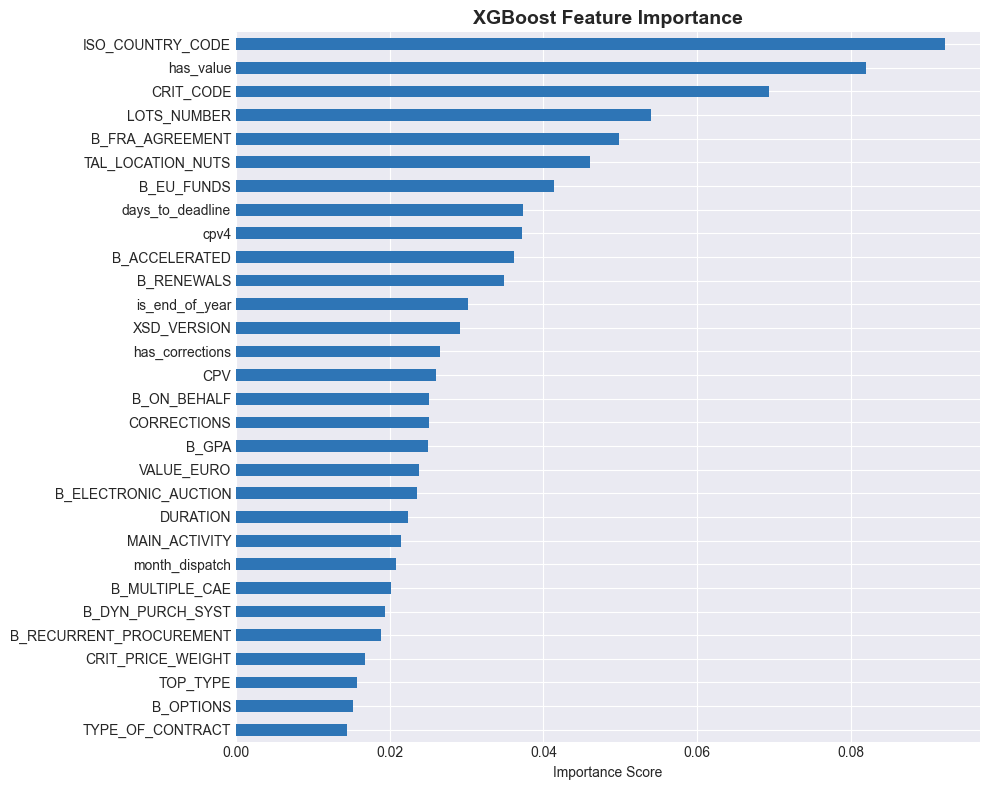

In [48]:
importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance_sorted = importance.sort_values(ascending=False)

print("=== Feature Importance ===")
print(importance_sorted.to_string())

# ── Graphique ──
fig, ax = plt.subplots(figsize=(10, 8))
importance_sorted.plot(kind='barh', ax=ax, color='#2E75B6')
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 2nd attempt

In [ ]:
select2_df = df_raw[available].copy()
print(f"✅ DataFrame : {select2_df.shape[0]:,} rows * {select2_df.shape[1]} columns")
select_df['awarded'] = select_df['FUTURE_CAN_ID'].notna().astype(int)
select_df = select_df.drop(columns=['FUTURE_CAN_ID'])

select_df['DT_DISPATCH'] = pd.to_datetime(select_df['DT_DISPATCH'], dayfirst=True, errors='coerce')
select_df['DT_APPLICATIONS'] = pd.to_datetime(select_df['DT_APPLICATIONS'], dayfirst=True, errors='coerce')

select_df['cpv4'] = select_df['CPV'].astype(str).str[:4]
select_df['month_dispatch'] = select_df['DT_DISPATCH'].dt.month
select_df['is_end_of_year'] = select_df['month_dispatch'].isin([11, 12]).astype(int)
select_df['days_to_deadline'] = (select_df['DT_APPLICATIONS'] - select_df['DT_DISPATCH']).dt.days.clip(0, 365).fillna(30)
select_df['has_value'] = (select_df['VALUE_EURO'] > 0).astype(int)
select_df['has_corrections'] = (select_df['CORRECTIONS'] > 0).astype(int)

select_df = select_df.drop(columns=['DT_DISPATCH', 'DT_APPLICATIONS'], errors='ignore')

df_v1 = select_df
print(f"New columns: {df_v1.shape[1]} total")

✅ DataFrame : 500,000 rows * 27 columns
